In [1]:
# Put import statements here
import sys
import subprocess
from pathlib import Path

# Local files/code
import src.data_preprocessing.image_preprocessing as img_pre
import src.data_preprocessing.text_preprocessing as text_pre
import src.data_preprocessing.text_data_exploration as text_explore
from src.agents.Visual_Agent import VisualModel
from src.util.logger import Logger
from src.util.config import config, PROJECT_ROOT
import src.util.general as general_util
from src.data_preprocessing.TextTokenizer import TextTokenizer

2026-09-11 09:00:51.360556: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-11 09:00:51.368461: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1789131651.377833   35980 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1789131651.380623   35980 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1789131651.388032   35980 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
# Run pytest setup tests to verify the environment/hardware is good to go
#subprocess.run(
#    [sys.executable, "-m", "pytest", "-q", "test/test_setup.py"],
#    check=False,
#)

In [2]:
# Determine the project's data repo location
DATA_DIR= PROJECT_ROOT / "data"


In [3]:
# load the plantExpertVQA training, validation, and testing datasets
plant_expert_vqa_data_path= DATA_DIR / config.data.PlantExpertVQA.data_path
plant_expert_vqa_path= DATA_DIR / "PlantExpertVQA"
train_data_path= plant_expert_vqa_data_path / config.data.PlantExpertVQA.train_file
test_data_path= plant_expert_vqa_data_path / config.data.PlantExpertVQA.test_file
validation_data_path= plant_expert_vqa_data_path / config.data.PlantExpertVQA.validation_file


plant_expert_vqa_TRAIN= text_pre.load_csv(train_data_path)
plant_expert_vqa_TEST= text_pre.load_csv(test_data_path)
plant_expert_vqa_VAL= text_pre.load_csv(validation_data_path)

09:01:07 [DEBUG   ]: [load_csv] Successfully loaded /mnt/c/Users/codyr/Code/AI-572/PlantQA/data/PlantExpertVQA/data/train.csv into dataframe


/mnt/c/Users/codyr/Code/AI-572/PlantQA/src/data_preprocessing/text_preprocessing.py:27: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  data= pd.read_csv(csv_path)


09:01:07 [DEBUG   ]: [load_csv] Successfully loaded /mnt/c/Users/codyr/Code/AI-572/PlantQA/data/PlantExpertVQA/data/test.csv into dataframe
09:01:08 [DEBUG   ]: [load_csv] Successfully loaded /mnt/c/Users/codyr/Code/AI-572/PlantQA/data/PlantExpertVQA/data/val.csv into dataframe


In [4]:
PEVQA_text_columns= general_util.parse_list_from_string(config.data.PlantExpertVQA.text_columns)
PEVQA_columns_to_remove= general_util.parse_list_from_string(config.data.PlantExpertVQA.columns_to_remove)
PEVQA_na_fill= vars(config.data.PlantExpertVQA.na_fill)

# preprocess (not tokenize) the training, testing, and validation datasets
# NOTE: the stop word removal may be too intense.  We most likely want to fine tune the stopword set, or define our own set
#       Right now it removes words like "what" and "why", which will most likely be bad for a VQA system that answers questions.

# training
text_pre.preprocess_dataframe(
    plant_expert_vqa_TRAIN,
    PEVQA_text_columns,
    PEVQA_columns_to_remove,
    PEVQA_na_fill,
    ["image_path"],
    plant_expert_vqa_path,
)

# testing
text_pre.preprocess_dataframe(
    plant_expert_vqa_TEST,
    PEVQA_text_columns,
    PEVQA_columns_to_remove,
    PEVQA_na_fill,
    ["image_path"],
    plant_expert_vqa_path,
)

#validation
text_pre.preprocess_dataframe(
    plant_expert_vqa_VAL,
    PEVQA_text_columns,
    PEVQA_columns_to_remove,
    PEVQA_na_fill,
    ["image_path"],
    plant_expert_vqa_path,
)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 535881 entries, 0 to 535880
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   qa_id              535881 non-null  object
 1   image_id           535881 non-null  object
 2   image_path         535881 non-null  object
 3   crop               535881 non-null  object
 4   disease            535881 non-null  object
 5   category           535881 non-null  object
 6   severity           535881 non-null  object
 7   question_text      535881 non-null  object
 8   answer             535881 non-null  object
 9   answer_type        535881 non-null  object
 10  question_category  535881 non-null  object
 11  cognitive_level    535881 non-null  object
dtypes: object(12)
memory usage: 49.1+ MB
09:01:19 [INFO    ]: Plant Expert VQA Training Dataset Info:
None



09:01:19 [INFO    ]: Plant Expert VQA Training Dataset Description:
                                      

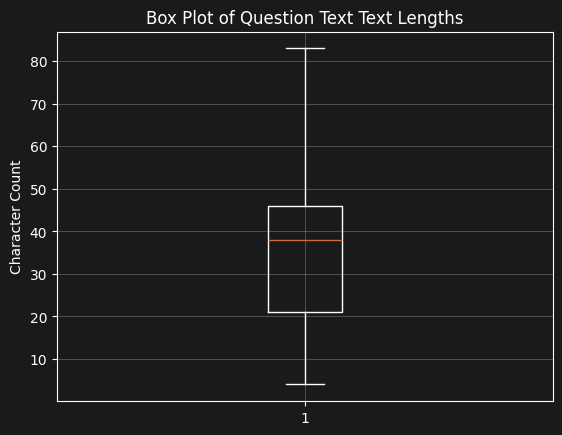

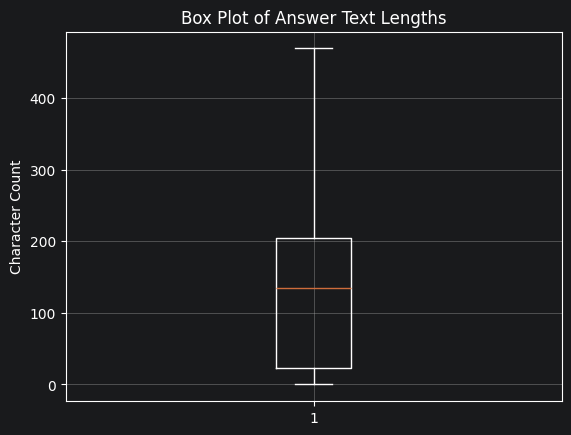







09:01:20 [INFO    ]: 

-------- Plant Expert VQA Training Dataset Class Frequency Distributions --------




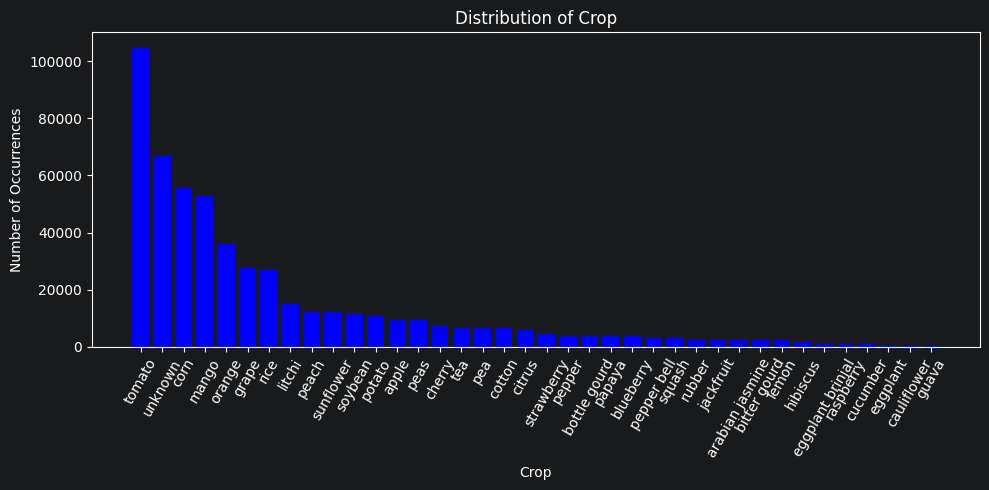

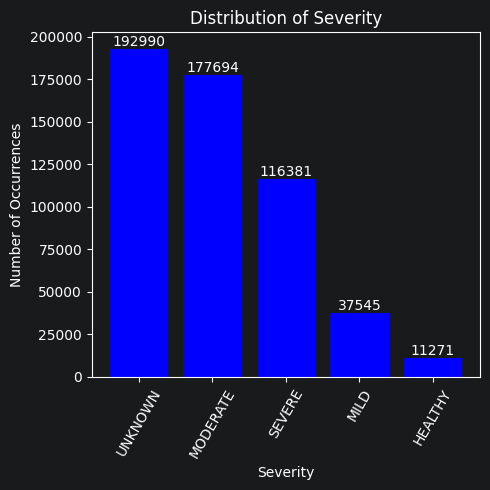

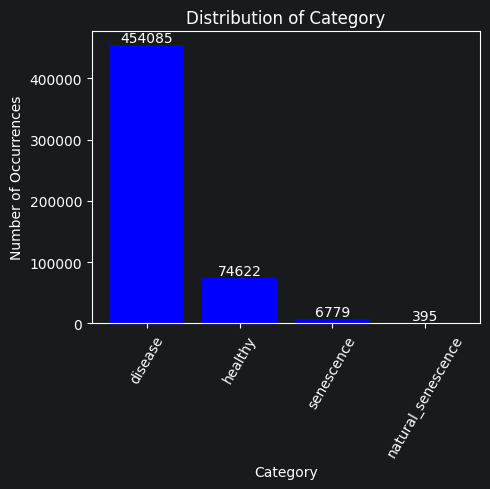

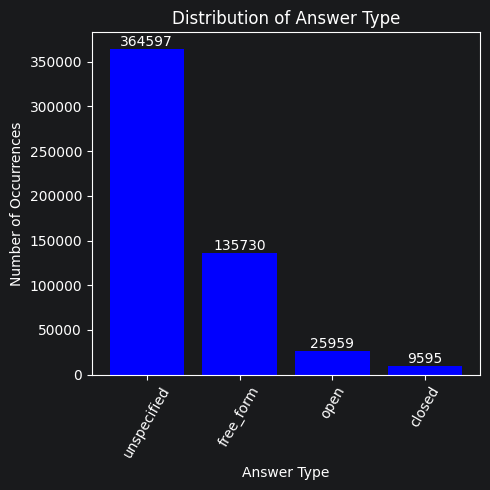

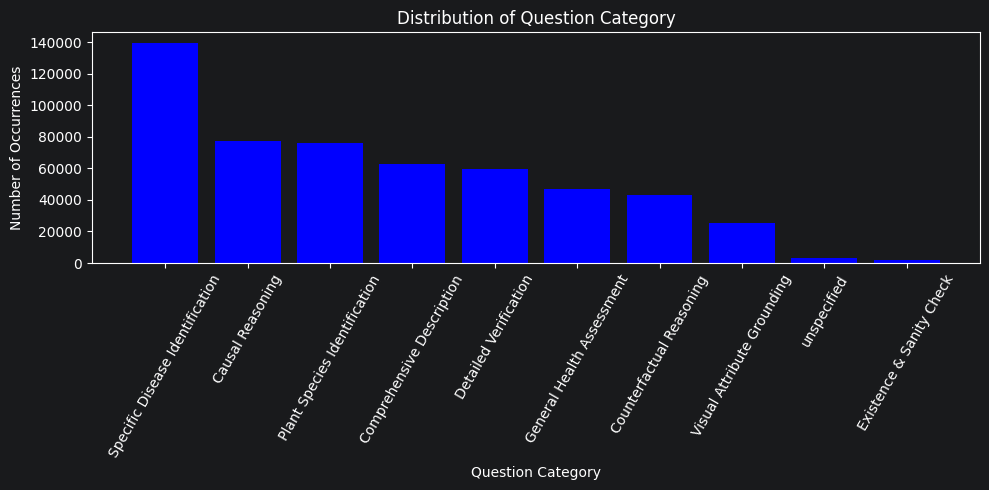







09:01:20 [INFO    ]: 

-------- Plant Expert VQA Training Dataset WordClouds --------




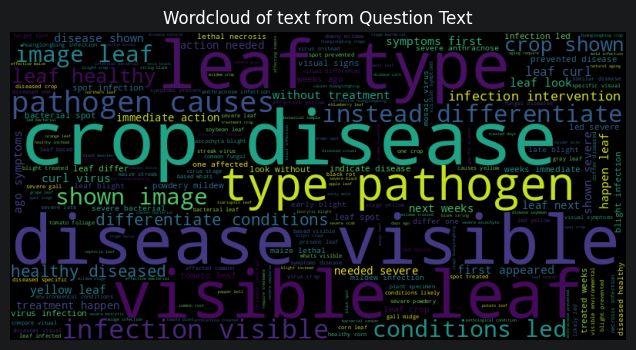

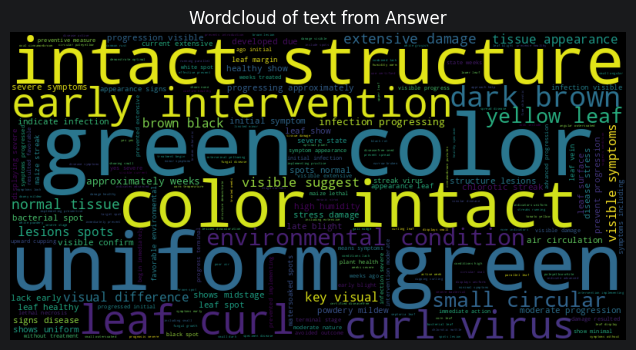







09:01:29 [INFO    ]: 

-------- Plant Expert VQA Training Dataset Word Frequency Distributions --------




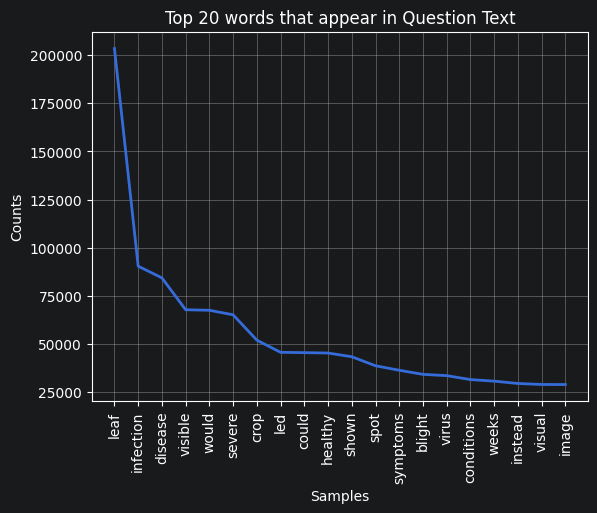

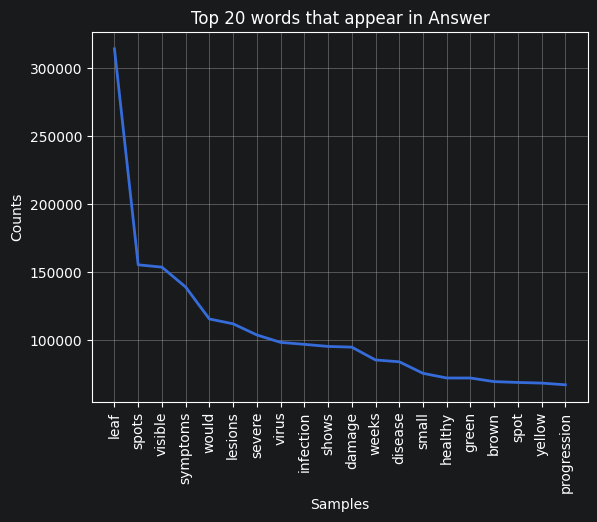

In [5]:

column_distribution_args= [
    {"column": "crop", "show_counts": False, "figure_size": (10, 5)},
    {"column": "severity", "show_counts": True, "figure_size": (5, 5)},
    {"column": "category", "show_counts": True, "figure_size": (5, 5)},
    {"column": "answer_type", "show_counts": True, "figure_size": (5, 5)},
    {"column": "question_category", "show_counts": False, "figure_size": (10, 5)},
]

# explore the cleaned training dataset
text_explore.explore_data(
    plant_expert_vqa_TRAIN, 
    column_distribution_args, 
    PEVQA_text_columns, 
    top_n_words=20, 
    name="Plant Expert VQA Training Dataset"
)

In [7]:
tokenizer= TextTokenizer("distilbert-base-uncased", 128)

encoding= tokenizer.encode_text("hello", None)

Logger.info(encoding)

23:46:47 [INFO    ]: {'input_ids': [[101, 7592, 102]], 'attention_mask': [[1, 1, 1]]}


/home/codyrgould/tf-gpu/lib/python3.11/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


23:46:47 [DEBUG   ]: Loaded image: /mnt/c/Users/codyr/Code/AI-572/PlantQA/data/PlantExpertVQA/images/51517fa78a37207e.jpg


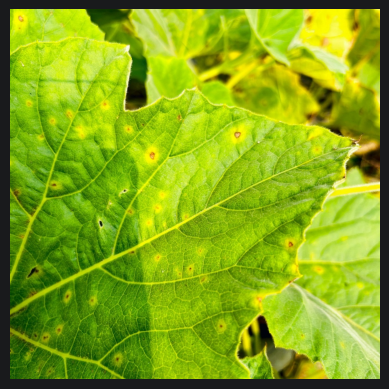

In [8]:
head= plant_expert_vqa_TRAIN.iloc()[0]
image_path= head["image_path"]
#full_image_path= DATA_DIR / "PlantExpertVQA" / image_path
img= img_pre.load_image(image_path)

img_pre.show_image(img)

In [6]:
# Adding on macbook - will need to retest on workstation later tonight due to GPU acceleration
IMAGES_ROOT = DATA_DIR / "PlantExpertVQA"
traits = ["crop", "disease", "category", "severity"]

classes = {}
for t in traits:
    names = sorted(plant_expert_vqa_TRAIN[t].unique())  # adds names of plants
    classes[t] = names + ["unknown"]  # adds unknown species

train_ds = VisualModel.make_dataset(plant_expert_vqa_TRAIN, classes, IMAGES_ROOT, training=True)
val_ds = VisualModel.make_dataset(plant_expert_vqa_VAL, classes, IMAGES_ROOT)

visual_model = VisualModel(classes=classes)
visual_model.build()
visual_model.compile()
visual_model.fit(train_ds, val_ds, epochs=20)

I0000 00:00:1789131693.817596   35980 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13495 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 SUPER, pci bus id: 0000:01:00.0, compute capability: 8.9


Epoch 1/20


I0000 00:00:1789131701.420124   36201 service.cc:152] XLA service 0x515bba60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1789131701.420170   36201 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4080 SUPER, Compute Capability 8.9
2026-09-11 09:01:41.567117: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1789131702.349087   36201 cuda_dnn.cc:529] Loaded cuDNN version 90300
2026-09-11 09:01:44.240345: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=0} for conv %cudnn-conv.119 = (f32[32,32,112,112]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,32,112,112]{3,2,1,0} %bitcast.33343, f32[32,1,3,3]{3,2,1,0} %bitcast.33350), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, feature_group_count=32, custom_call_target="__cudnn$convForward", metadata={op_type="Depthw

    4/16747 ━━━━━━━━━━━━━━━━━━━━ 15:00 54ms/step - category_accuracy: 0.3145 - category_loss: 1.4747 - crop_accuracy: 0.0039 - crop_loss: 3.9880 - disease_accuracy: 0.0104 - disease_loss: 5.0517 - loss: 9.8099 - severity_accuracy: 0.8320 - severity_loss: 1.0927    

I0000 00:00:1789131717.043879   36201 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


16747/16747 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - category_accuracy: 0.9945 - category_loss: 0.0205 - crop_accuracy: 0.9534 - crop_loss: 0.1797 - disease_accuracy: 0.8880 - disease_loss: 0.4855 - loss: 0.7208 - severity_accuracy: 0.9496 - severity_loss: 0.1648

2026-09-11 09:15:45.065915: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_5', 56 bytes spill stores, 56 bytes spill loads

2026-09-11 09:15:45.187934: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_5', 156 bytes spill stores, 156 bytes spill loads

2026-09-11 09:15:45.221512: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_5', 1148 bytes spill stores, 1148 bytes spill loads

2026-09-11 09:15:45.549681: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_5', 1944 bytes spill stores, 1944 bytes spill loads

2026-09-11 09:15:45.648675: I external/loc

16747/16747 ━━━━━━━━━━━━━━━━━━━━ 959s 56ms/step - category_accuracy: 0.9761 - category_loss: 0.0827 - crop_accuracy: 0.8605 - crop_loss: 0.4080 - disease_accuracy: 0.8424 - disease_loss: 0.5223 - loss: 1.0101 - severity_accuracy: 0.9440 - severity_loss: 0.1833 - val_category_accuracy: 0.8498 - val_category_loss: 0.7023 - val_crop_accuracy: 0.4719 - val_crop_loss: 1.9318 - val_disease_accuracy: 0.2414 - val_disease_loss: 3.8986 - val_loss: 7.6302 - val_severity_accuracy: 0.3961 - val_severity_loss: 5.2970
Epoch 2/20
16747/16747 ━━━━━━━━━━━━━━━━━━━━ 895s 53ms/step - category_accuracy: 0.9768 - category_loss: 0.0790 - crop_accuracy: 0.8693 - crop_loss: 0.3611 - disease_accuracy: 0.8552 - disease_loss: 0.4537 - loss: 0.8969 - severity_accuracy: 0.9427 - severity_loss: 0.1948 - val_category_accuracy: 0.8442 - val_category_loss: 0.7726 - val_crop_accuracy: 0.5261 - val_crop_loss: 1.6249 - val_disease_accuracy: 0.2755 - val_disease_loss: 3.8113 - val_loss: 7.4375 - val_severity_accuracy: 0.37

In [7]:
import json
Path("./models/visual_models/9_10_classes.json").write_text(json.dumps(classes))
visual_model.save(path="./models/visual_models/9_10.keras")